# Executive Summary 

This project is based on a dataset gotten from a health and wellness app that helps users keep track of their sleep, activity, and general health habits. The data isn’t very large, so it may not be ideal for making broad conclusions, but it still gives us interesting insights into how our sleep, stress, and daily habits affect our overall well-being.

This dataset contains details like age, gender, occupation, sleep hours, sleep quality, physical activity level, stress level, BMI, heart rate, blood pressure, and sleep disorders.

After cleaning the data, I worked with the following main features:

**Demographics:** Gender, Age, Occupation

**Sleep Metrics:** Sleep Hours, Sleep Quality, Sleep Disorder 

**Lifestyle Metrics:** Physical Activity Level, Stress Level, Daily Steps

**Health Metrics:** BMI, Heart Rate, Systolic & Diastolic Blood Pressure, and Pulse Pressure (calculated as Systolic − Diastolic)

This analysis explores how factors like occupation, stress, and physical activity affect sleep and health. Even though it’s a small dataset, it clearly shows that people who are more active and manage stress better tend to sleep longer and have better heart health.

In short, this project gives us a small but meaningful picture of how our lifestyle choices — especially how we sleep, move, and handle stress — reflect in our overall health.


## 💾 The data

SleepInc has provided you with an anonymized dataset of sleep and lifestyle metrics for 374 individuals. This dataset contains average values for each person calculated over the past six months.

The dataset includes 13 columns covering sleep duration, quality, disorders, exercise, stress, diet, demographics, and other factors related to sleep health. 

| Column | Description |
|---------|----------------------------------------|  
| `Person ID` | An identifier for each individual. |
| `Gender` | The gender of the person (Male/Female). |  
| `Age` | The age of the person in years. |
| `Occupation` | The occupation or profession of the person. |
| `Sleep Duration (hours)` | The average number of hours the person sleeps per day. |
| `Quality of Sleep (scale: 1-10)` | A subjective rating of the quality of sleep, ranging from 1 to 10. |
| `Physical Activity Level (minutes/day)` | The average number of minutes the person engages in physical activity daily. |  
| `Stress Level (scale: 1-10)` | A subjective rating of the stress level experienced by the person, ranging from 1 to 10. |
| `BMI Category` | The BMI category of the person (e.g., Underweight, Normal, Overweight). |
| `Blood Pressure (systolic/diastolic)` | The average blood pressure measurement of the person, indicated as systolic pressure over diastolic pressure. |
| `Heart Rate (bpm)` | The average resting heart rate of the person in beats per minute. |
| `Daily Steps` | The average number of steps the person takes per day. |
| `Sleep Disorder` | The presence or absence of a sleep disorder in the person (None, Insomnia, Sleep Apnea). |

***Acknowledgments**: Laksika Tharmalingam, Kaggle: https://www.kaggle.com/datasets/uom190346a/sleep-health-and-lifestyle-dataset* (this is a fictitious dataset)

# Data Cleaning and Exploration

 We cleaned the data and got it ready for exploration and analysis. Here’s what we did step by step:

- Renaming of Columns
We renamed the columns and removed white spaces so they can be easy to read.

- Checked for  duplicates
We found some duplicates in the data and removed them. This reduced the number of rows from 374 to 132.

- Checked for Null Values
We found that the column Sleep Disorder contains null values. It absolutely means that those who left this column blank had no sleep disorder. we replaced the null values with 'None'.

- We created a binary column: 1 for those with sleep disorder and 0 for those without sleep disorder.

- I split the blood pressure column into two new columns to help our analysis: systolic pressure for the number up and diastolic pressure for the number down.

- An additional column called pulse pressure will be created. we get this new column by subtracting the diastolic from the systolic pressure. This is to enhaace decision making from our data.




In [130]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('Sleep_health_and_lifestyle_dataset (1).csv')
df

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,None
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,370,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
370,371,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
371,372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
372,373,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea


In [131]:
df.rename(columns = {
    "Person ID": "ID",
    "Gender": "gender",
    "Age": "age",
    "Occupation": "occupation",
    "Sleep Duration": "sleep_hrs",
    "Quality of Sleep": "sleep_quality",
    "Physical Activity Level": "physical_activity_level",
    "Stress Level": "stress_level",
    "BMI Category": "BMI",
    "Blood Pressure": "blood_pressure",
    "Heart Rate": "heart_rate",
    "Daily Steps": "daily_steps",
    "Sleep Disorder": "sleep_disorder",
    }, inplace = True )

In [132]:
df

,ID,gender,age,occupation,sleep_hrs,sleep_quality,physical_activity_level,stress_level,BMI,blood_pressure,heart_rate,daily_steps,sleep_disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,None
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,370,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
370,371,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
371,372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
372,373,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea


In [133]:
df = df.drop('ID', axis=1)


In [134]:
df.duplicated().sum()


242

In [135]:
df.drop_duplicates(inplace = True )

In [136]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 132 entries, 0 to 366
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   gender                   132 non-null    object 
 1   age                      132 non-null    int64  
 2   occupation               132 non-null    object 
 3   sleep_hrs                132 non-null    float64
 4   sleep_quality            132 non-null    int64  
 5   physical_activity_level  132 non-null    int64  
 6   stress_level             132 non-null    int64  
 7   BMI                      132 non-null    object 
 8   blood_pressure           132 non-null    object 
 9   heart_rate               132 non-null    int64  
 10  daily_steps              132 non-null    int64  
 11  sleep_disorder           132 non-null    object 
dtypes: float64(1), int64(6), object(5)
memory usage: 13.4+ KB


In [137]:
df.describe()

,age,sleep_hrs,sleep_quality,physical_activity_level,stress_level,heart_rate,daily_steps
count,132.000000,132.000000,132.000000,132.000000,132.000000,132.000000,132.000000
mean,41.128788,7.082576,7.151515,58.393939,5.537879,71.204545,6637.878788
std,8.813942,0.775335,1.269037,20.468840,1.740428,4.867306,1766.288657
min,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,33.750000,6.400000,6.000000,44.250000,4.000000,68.000000,5000.000000
50%,41.000000,7.150000,7.000000,60.000000,6.000000,70.000000,7000.000000
75%,49.000000,7.725000,8.000000,75.000000,7.000000,74.000000,8000.000000
max,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


In [138]:
# Let us check for null values
df.isna().sum()


gender                     0
age                        0
occupation                 0
sleep_hrs                  0
sleep_quality              0
physical_activity_level    0
stress_level               0
BMI                        0
blood_pressure             0
heart_rate                 0
daily_steps                0
sleep_disorder             0
dtype: int64

In [139]:
df.isna().sum()/df.shape[0]

gender                     0.0
age                        0.0
occupation                 0.0
sleep_hrs                  0.0
sleep_quality              0.0
physical_activity_level    0.0
stress_level               0.0
BMI                        0.0
blood_pressure             0.0
heart_rate                 0.0
daily_steps                0.0
sleep_disorder             0.0
dtype: float64

In [140]:
df['sleep_disorder'].value_counts(dropna=False)

None           73
Sleep Apnea    30
Insomnia       29
Name: sleep_disorder, dtype: int64

In [141]:

# We created a binary column and categorised the sleep disorder column into 0 and 1. 1 is for anyone with sleep disorder and 0 for anyone without sleep disorder

df["has_sleep_disorder"] = df["sleep_disorder"] .apply (lambda x: 1 if x != "None" else 0)

In [142]:
# We split the blood pressure column into two: The number up is the systolic pressure and the number down is the diastolic pressure.
# An additional column called pulse pressure wwill be created. we get this new column by subtracting the diastolic from the systolic pressure. This is to enhaace decision making from our data
# The original blood pressure column will be deleted.

df[['systolic_BP', 'diastolic_BP']] = df['blood_pressure'].str.split('/', expand=True)



In [143]:
df

,gender,age,occupation,sleep_hrs,sleep_quality,physical_activity_level,stress_level,BMI,blood_pressure,heart_rate,daily_steps,sleep_disorder,has_sleep_disorder,systolic_BP,diastolic_BP
0,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,None,0,126,83
1,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None,0,125,80
3,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,1,140,90
5,Male,28,Software Engineer,5.9,4,30,8,Obese,140/90,85,3000,Insomnia,1,140,90
6,Male,29,Teacher,6.3,6,40,7,Obese,140/90,82,3500,Insomnia,1,140,90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
358,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,None,0,140,95
359,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,None,0,140,95
360,Female,59,Nurse,8.2,9,75,3,Overweight,140/95,68,7000,Sleep Apnea,1,140,95
364,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea,1,140,95


In [144]:

df.drop(columns=['blood_pressure'], inplace=True)



In [145]:
# We converted the new columns to integers

df['systolic_BP'] = df['systolic_BP'].astype(int)
df['diastolic_BP'] = df['diastolic_BP'].astype(int)



In [146]:
# We created another new column pulse pressure to get more insight from the blood pressure(systolic minus diastolic)

df['pulse_pressure'] = df['systolic_BP'] - df['diastolic_BP']




In [147]:

# Confirming the result

print(df[['systolic_BP', 'diastolic_BP', 'pulse_pressure']].head())

   systolic_BP  diastolic_BP  pulse_pressure
0          126            83              43
1          125            80              45
3          140            90              50
5          140            90              50
6          140            90              50


In [148]:
# Checking the column occupation

df["occupation"].value_counts()

Nurse                   29
Doctor                  24
Engineer                22
Teacher                 15
Lawyer                  15
Accountant              11
Salesperson              9
Software Engineer        3
Scientist                2
Sales Representative     1
Manager                  1
Name: occupation, dtype: int64

In [149]:
# Salesperson and sales representative will be caategorised as the same thing. All other professions less than 5 will be categorised as others.

df['occupation'] = df['occupation'].replace(['Sales Representative'], 'Salesperson')




In [150]:

df['occupation'] = df['occupation'].replace(['Manager', 'Scientist', 'Software Engineer'], 'Others')



In [151]:
# Checking the result

df

,gender,age,occupation,sleep_hrs,sleep_quality,physical_activity_level,stress_level,BMI,heart_rate,daily_steps,sleep_disorder,has_sleep_disorder,systolic_BP,diastolic_BP,pulse_pressure
0,Male,27,Others,6.1,6,42,6,Overweight,77,4200,None,0,126,83,43
1,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,None,0,125,80,45
3,Male,28,Salesperson,5.9,4,30,8,Obese,85,3000,Sleep Apnea,1,140,90,50
5,Male,28,Others,5.9,4,30,8,Obese,85,3000,Insomnia,1,140,90,50
6,Male,29,Teacher,6.3,6,40,7,Obese,82,3500,Insomnia,1,140,90,50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
358,Female,59,Nurse,8.0,9,75,3,Overweight,68,7000,None,0,140,95,45
359,Female,59,Nurse,8.1,9,75,3,Overweight,68,7000,None,0,140,95,45
360,Female,59,Nurse,8.2,9,75,3,Overweight,68,7000,Sleep Apnea,1,140,95,45
364,Female,59,Nurse,8.0,9,75,3,Overweight,68,7000,Sleep Apnea,1,140,95,45


In [152]:
# Confirming our data types
df.dtypes


gender                      object
age                          int64
occupation                  object
sleep_hrs                  float64
sleep_quality                int64
physical_activity_level      int64
stress_level                 int64
BMI                         object
heart_rate                   int64
daily_steps                  int64
sleep_disorder              object
has_sleep_disorder           int64
systolic_BP                  int64
diastolic_BP                 int64
pulse_pressure               int64
dtype: object

In [153]:
# Here, i grouped by Occupation and calculate mean sleep duration and stress level
occupation_stats = df.groupby('occupation')[['sleep_hrs', 'stress_level']].mean().round(2)

print(occupation_stats)



             sleep_hrs  stress_level
occupation                          
Accountant        7.14          4.82
Doctor            7.05          6.54
Engineer          7.80          4.23
Lawyer            7.38          5.13
Nurse             6.97          5.76
Others            6.40          6.33
Salesperson       6.37          7.10
Teacher           6.72          5.00


In [154]:
import seaborn as sns

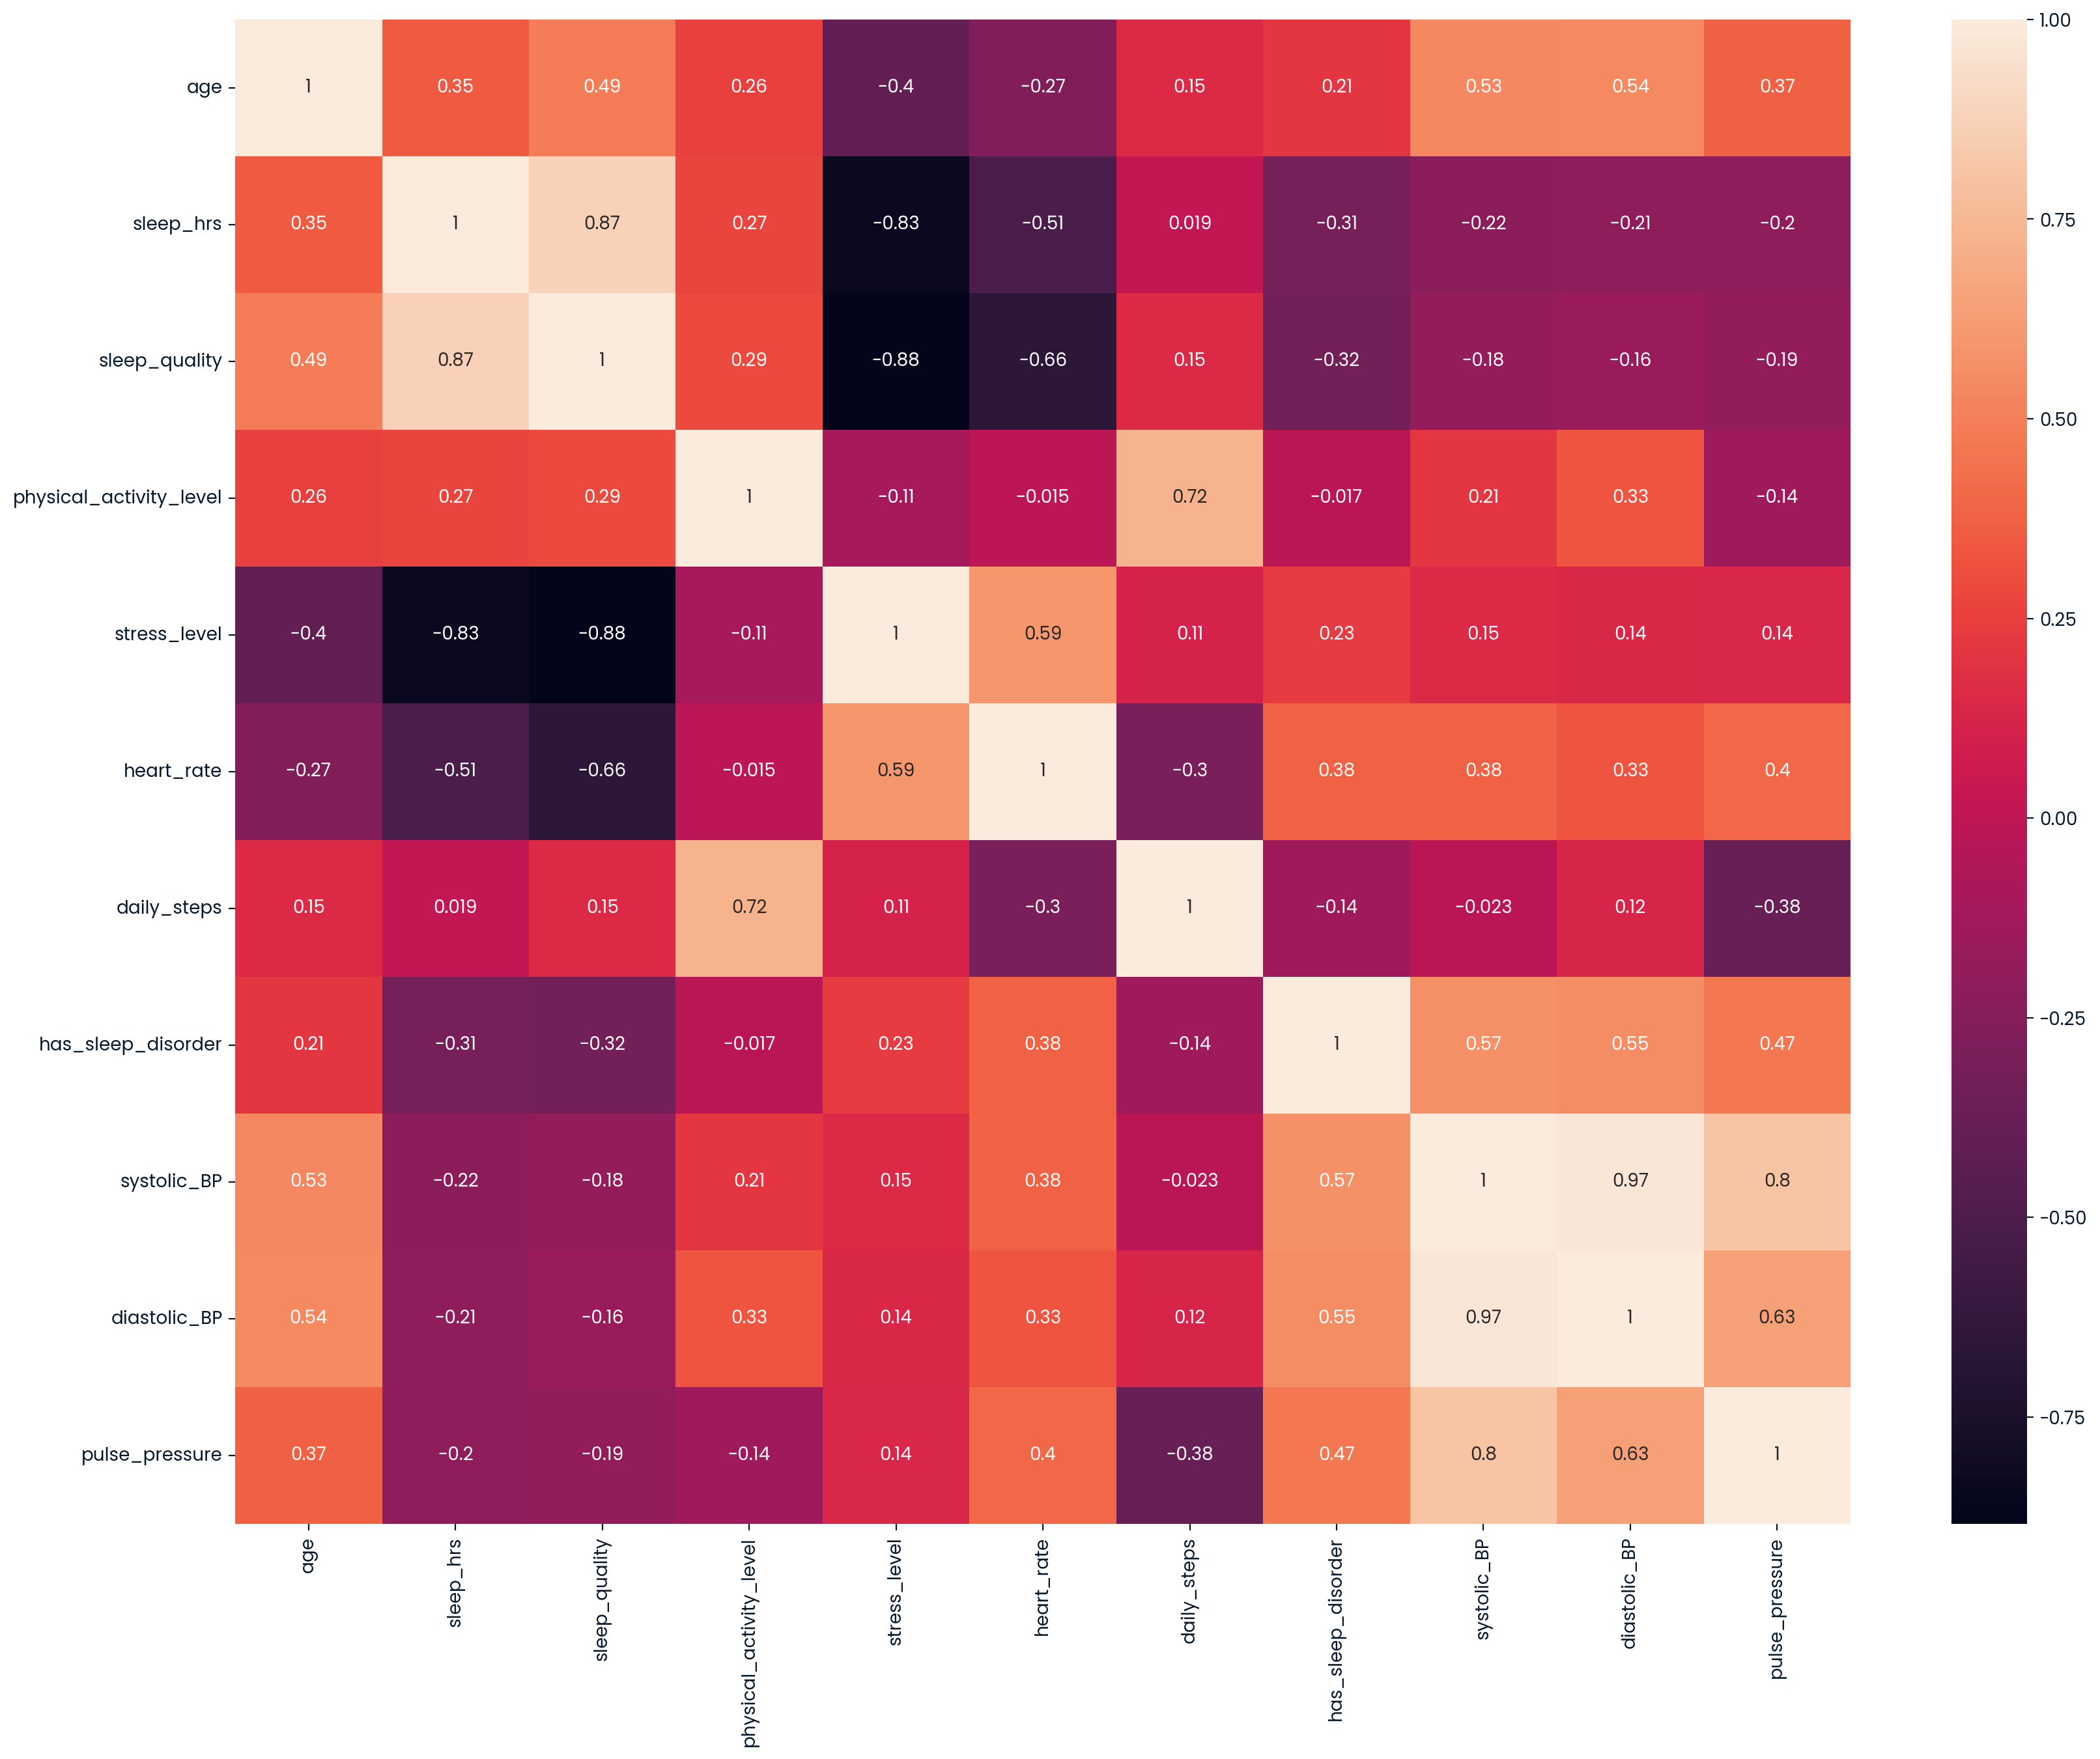

In [155]:
plt.figure(figsize=(20, 15))
sns.heatmap(df.corr(numeric_only = True), annot=True);


### Insights from the Correlation Heatmap

From the heatmap, we noticed some interesting relationships between lifestyle, sleep, and health indicators:

Sleep duration and sleep quality are strongly and positively related — it means that people who sleep longer tend to enjoy better sleep quality.

Stress level has a strong negative correlation with both sleep duration and sleep quality. In other words, higher stress is linked to poor sleep.

Physical activity level shows a moderate positive relationship with daily steps and a negative relationship with stress, suggesting that being active may help reduce stress levels.

Systolic and diastolic blood pressure are, as expected, highly correlated with each other and also show some relationship with pulse pressure.

Heart rate has a mild negative correlation with sleep quality — people with better sleep tend to have slightly lower heart rates.

Sleep disorder is moderately linked to higher blood pressure and stress or or cardiovascular strain.

Overall, even though the dataset is not large enough to make broad generalizations, it still gives useful insights into how sleep, stress, and physical activity are connected to our overall health.

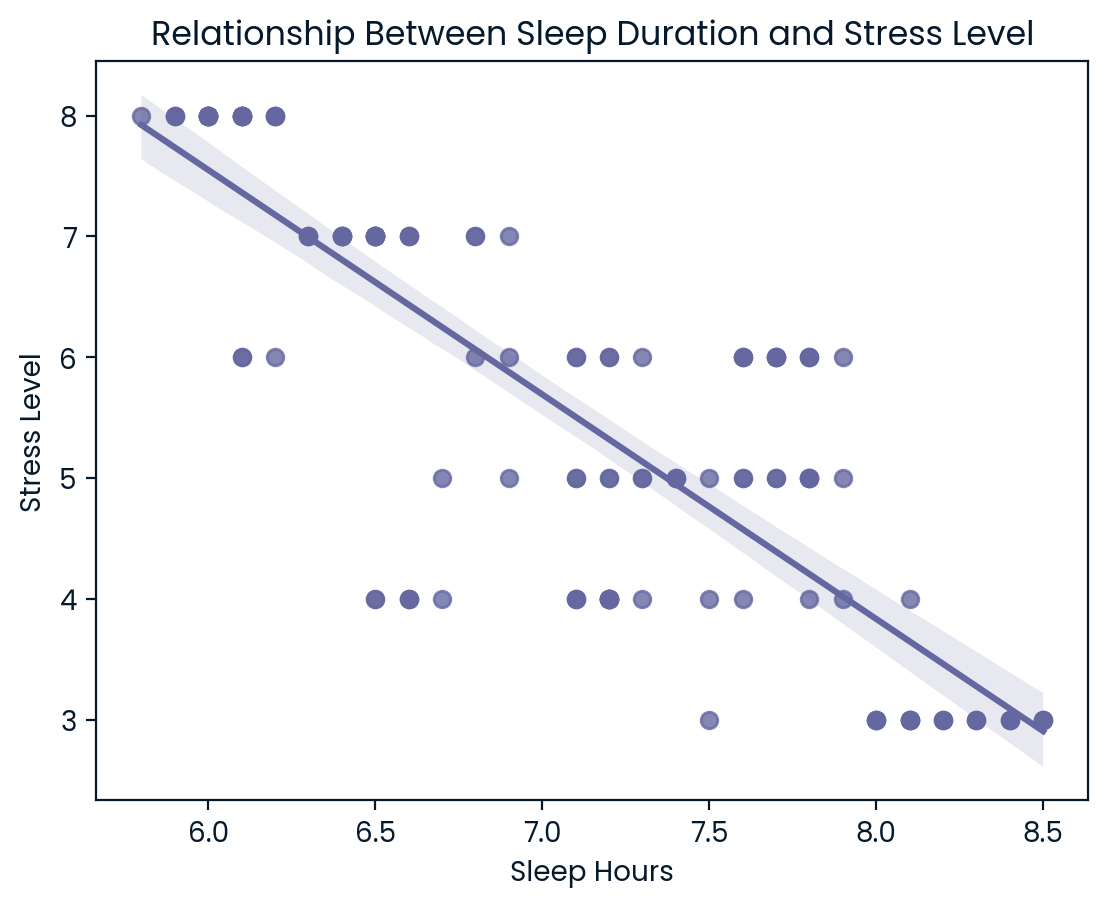

In [156]:
sns.regplot(x='sleep_hrs', y='stress_level', data=df)
plt.title('Relationship Between Sleep Duration and Stress Level')
plt.xlabel('Sleep Hours')
plt.ylabel('Stress Level')
plt.show()


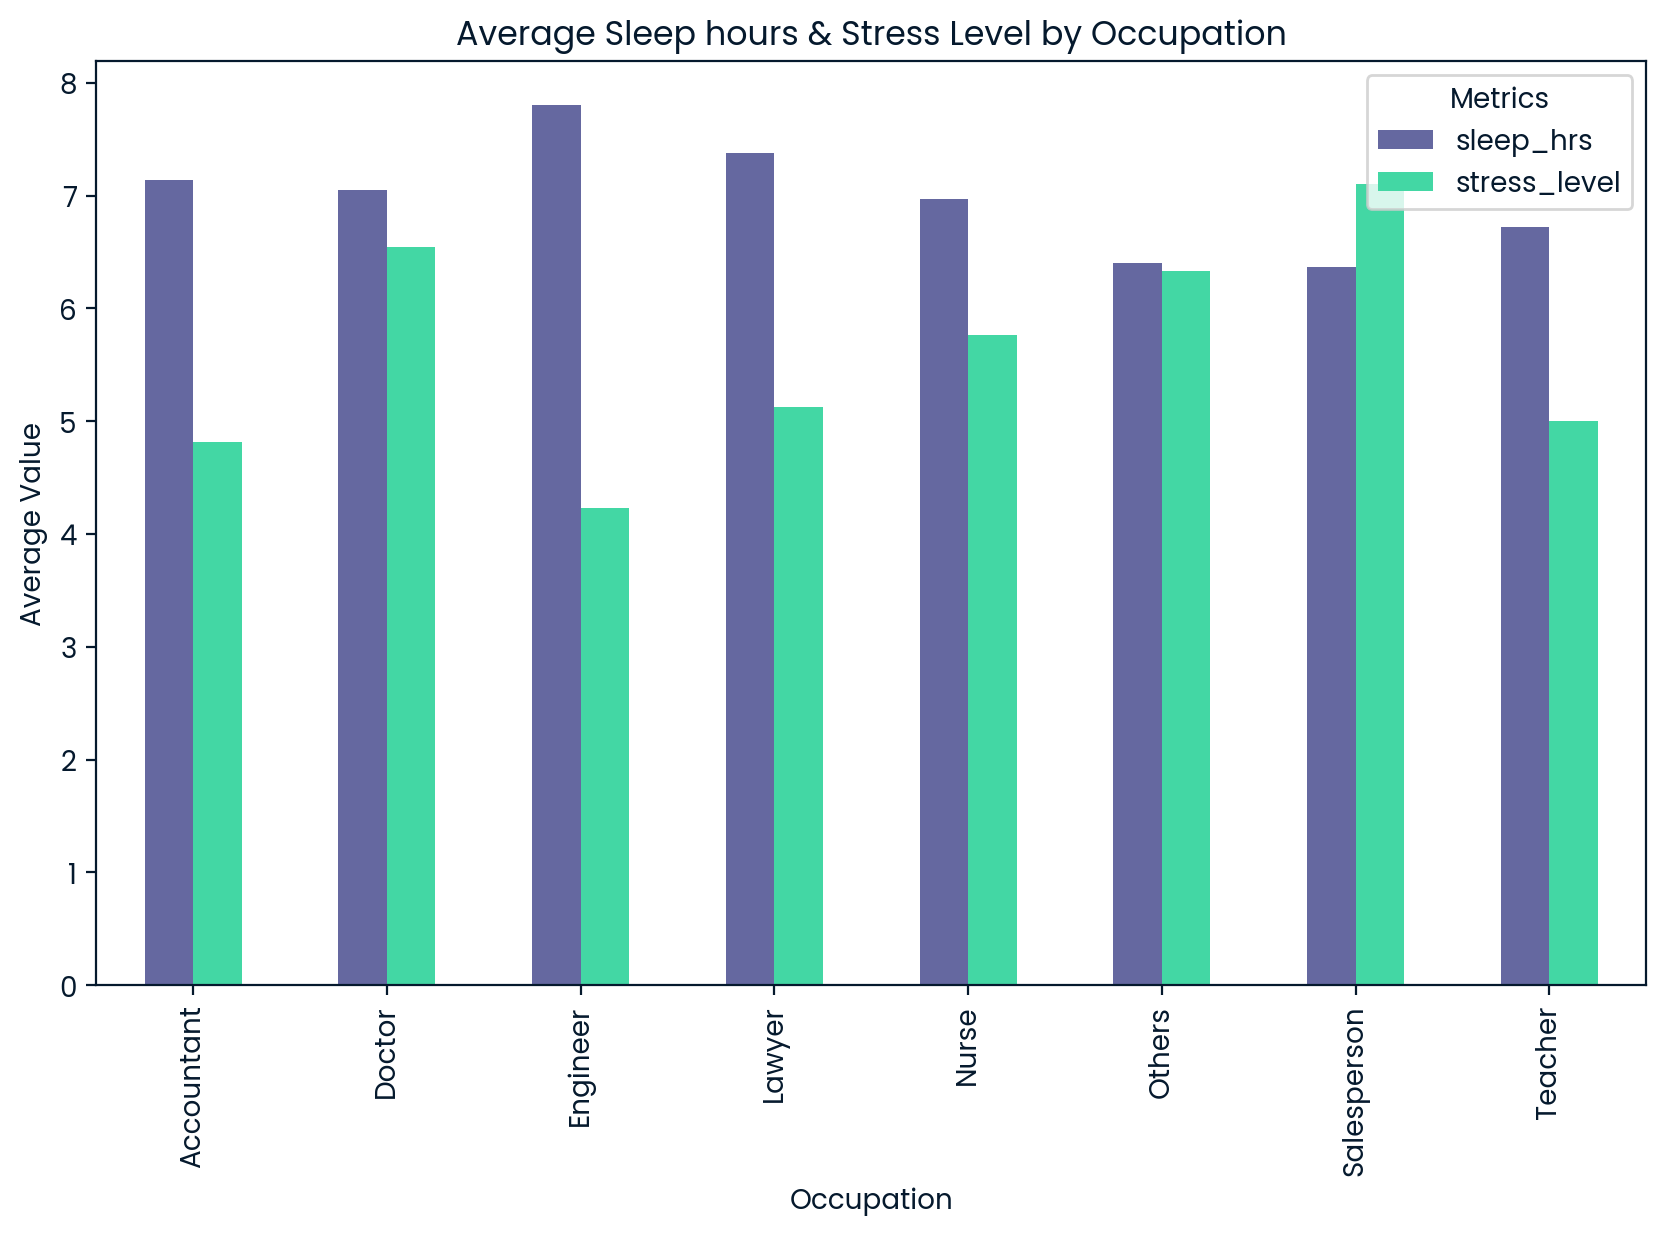

In [157]:
occupation_stats.plot(kind='bar', figsize=(10,6))
plt.title('Average Sleep hours & Stress Level by Occupation')
plt.xlabel('Occupation')
plt.ylabel('Average Value')
plt.legend(title='Metrics')
plt.show()



#### From the above
People working as sales representatives and salespersons tend to have shorter sleep durations and higher stress levels compared to others. This might be due to their fast-paced, target-driven jobs.

Managers, engineers, and scientists (grouped as “others”) show slightly better sleep patterns and lower stress levels, possibly because of more stable or structured work routines.

Nurses and teachers fall somewhere in the middle — they don’t get the best sleep, but their stress levels aren’t the highest either.

Overall, there seems to be a visible relationship between job type, sleep, and stress, reinforcing the idea that lifestyle and occupation can influence health and sleep quality.

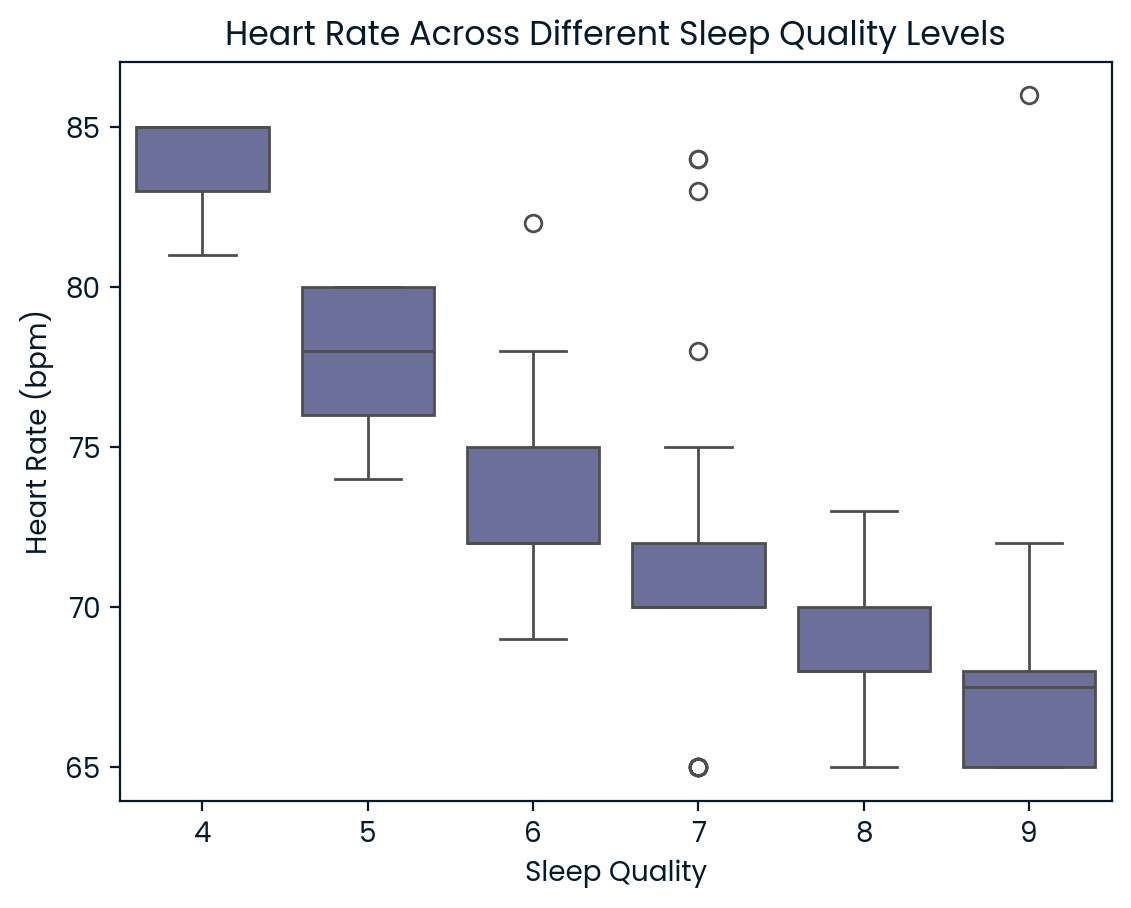

In [158]:

sns.boxplot(x='sleep_quality', y='heart_rate', data=df)
plt.title('Heart Rate Across Different Sleep Quality Levels')
plt.xlabel('Sleep Quality')
plt.ylabel('Heart Rate (bpm)')
plt.show()


#### The above shows that people with higher sleep quality tend to have lower heart rates.


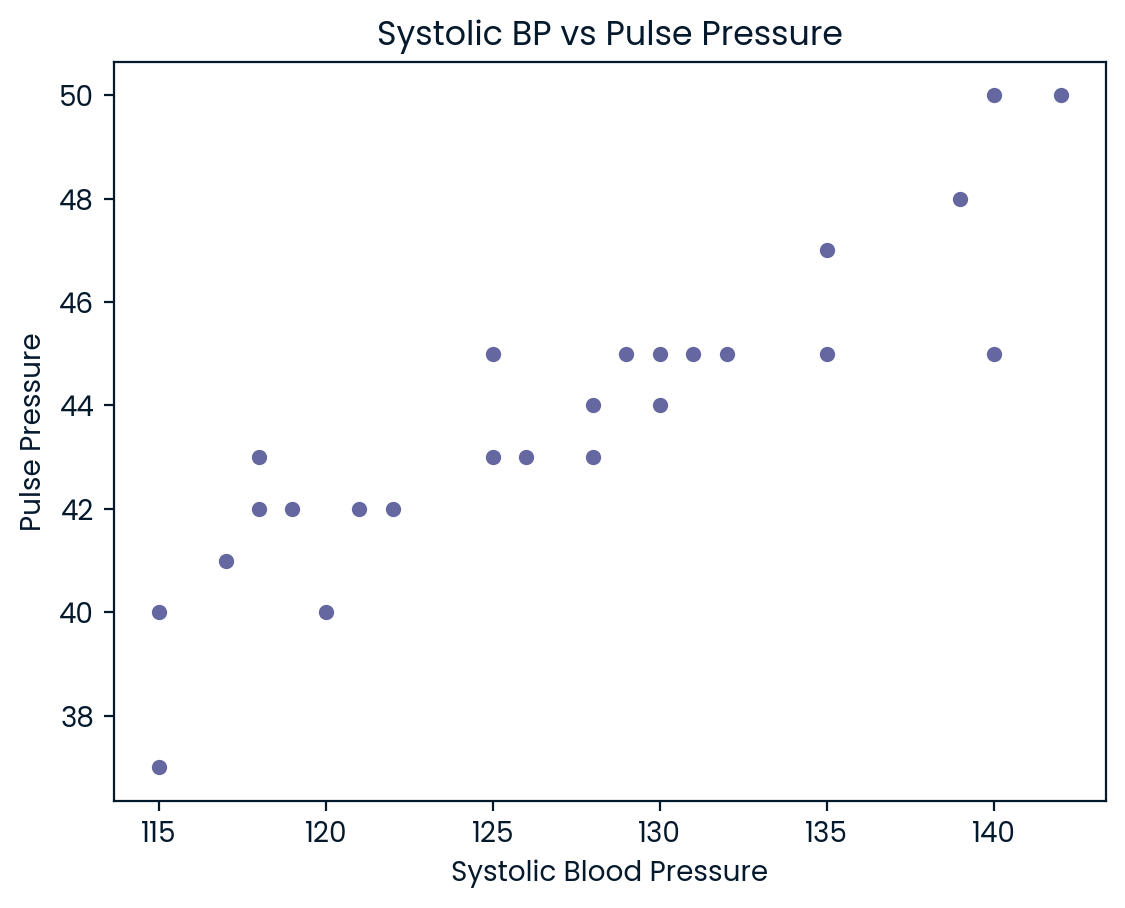

In [159]:
sns.scatterplot(x='systolic_BP', y='pulse_pressure', data=df)
plt.title('Systolic BP vs Pulse Pressure')
plt.xlabel('Systolic Blood Pressure')
plt.ylabel('Pulse Pressure')
plt.show()



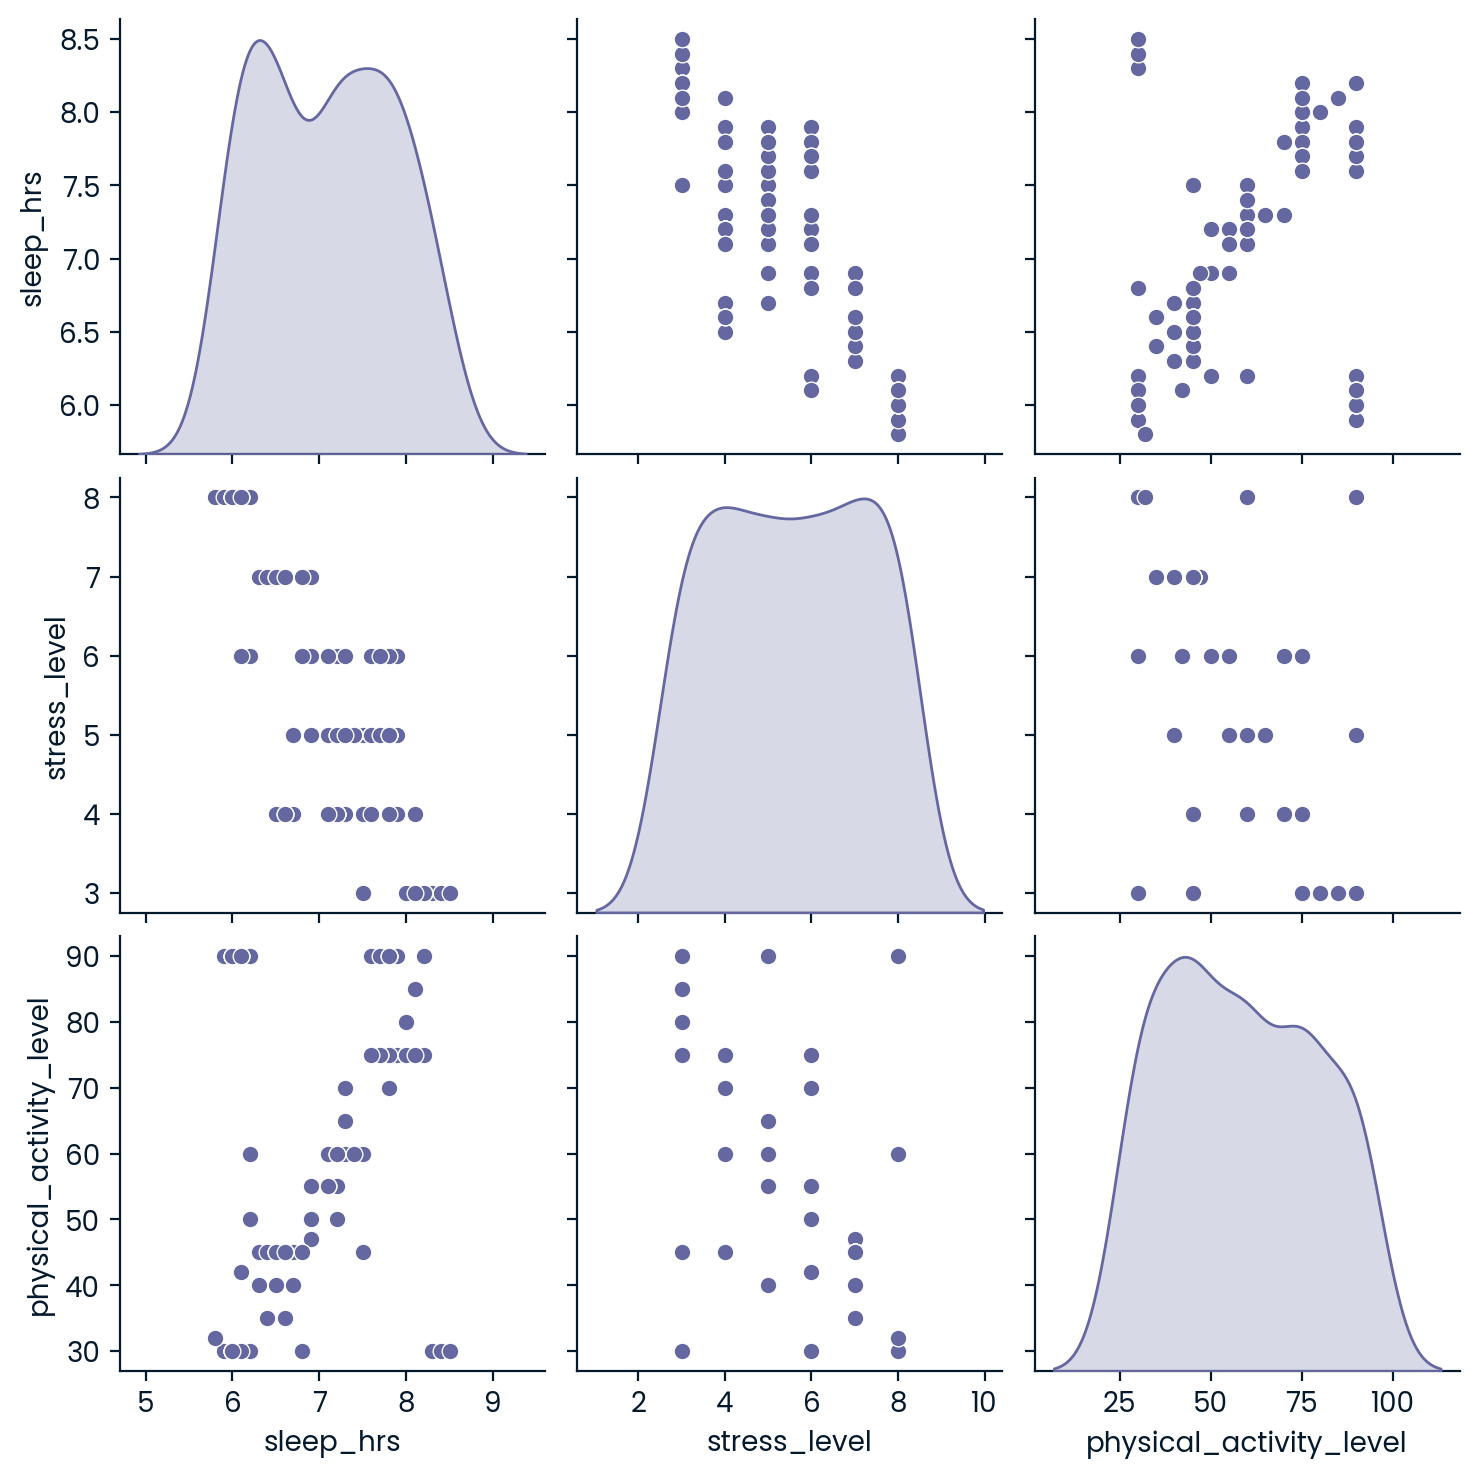

In [160]:

sns.pairplot(df[['sleep_hrs', 'stress_level', 'BMI', 'physical_activity_level']], diag_kind='kde')
plt.show()


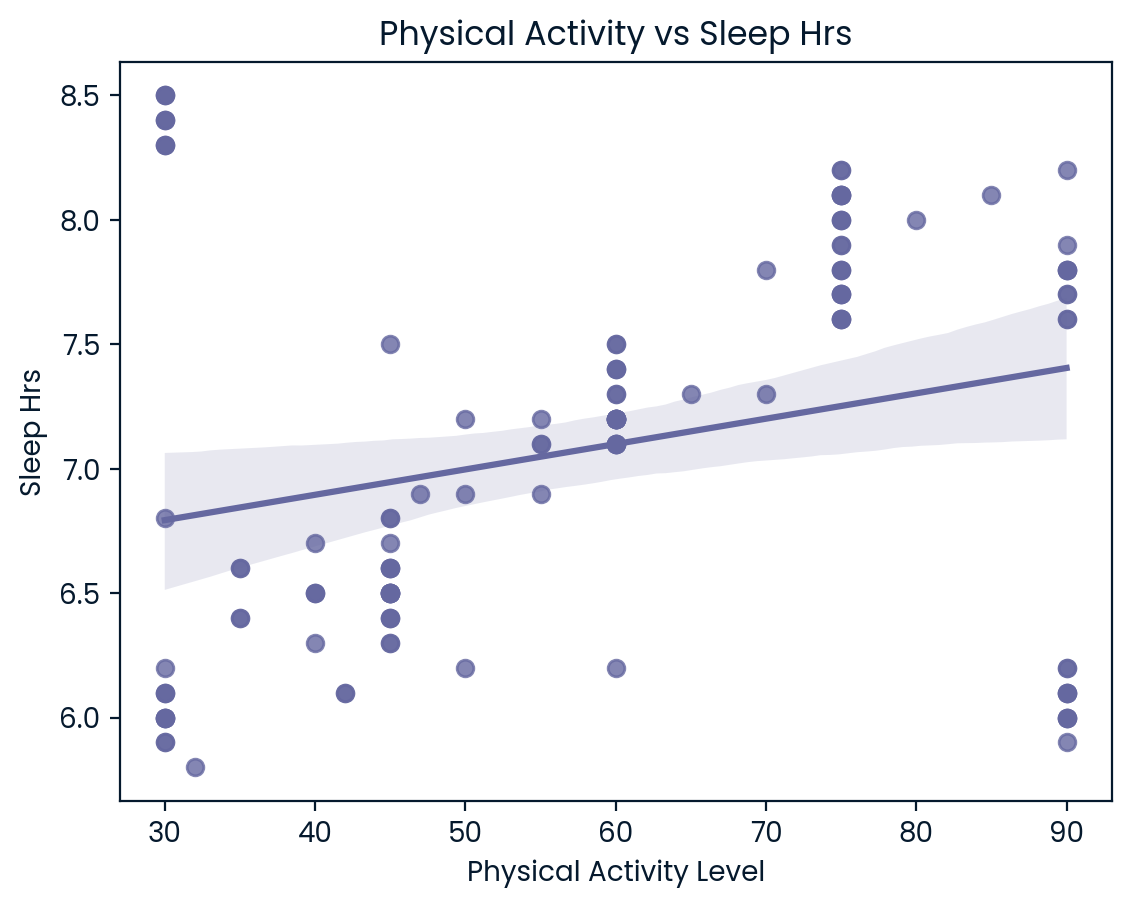

In [161]:
sns.regplot(x='physical_activity_level', y='sleep_hrs', data=df)
plt.title('Physical Activity vs Sleep Hrs')
plt.xlabel('Physical Activity Level')
plt.ylabel('Sleep Hrs')
plt.show()



# FINDINGS AND RECOMMENDATIONS ON WAYS PEOPLE CAN IMPOROVE SLEEP HEALTH BASED ON DATA VISUALS

1. Manage Stress Level
Findings: Visuals shows that Individuals with higher stress levels are associated with poorer sleep outcome.
 We recommend that people practice relaxation before bed • Avoid heavy mental tasks, work emails, or screen time an hour before bedtime. • Create a calm bedtime routine (low lights, quiet music, or reading). • Seek professional help if stress feels overwhelming.

2. Increase Physical Activity
Findings: Visuals shows increase in Physical Activity level relates well with longer Sleep duration.
Recommendation: Engage in moderate exercise(walking, jogging or light yoga stretch) and a nice shower afterwards before bedtime. This helps to reduce anxiety, relax the mind and leads to deeper sleep.

3. Age-Related Adjustments
Findings: Aging changes sleep cycles — older adults may get less deep sleep but still need good rest quality.
Recommendations: Stick to a consistent routine, Avoid caffeine in the afternoon and Limit afternoon naps.

4. Occupational Influence on Sleep Quantity
Findings: Certain occupations are linked to shorter sleep duration. This might be due to their fast-paced, target-driven jobs.
Recommendations: Employers should promote work-life balance and workers should Take breaks during the day and limit screen use right before bed.



